In [4]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False


In [5]:
df = pd.read_csv('../data/pima-indians-diabetes.data.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [6]:
df.corr() # 상관관계: 절대적인 지표가 아님, 상황에 따라 적절히 사용

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [7]:
x_data = df.iloc[:, :-1].values
y_data = df.iloc[:, -1].values

In [8]:
x_data.shape

(768, 8)

In [9]:
# [특성 데이터 train, 특성 데이터 test, 라벨 train, 라벨 test]
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.3, stratify=y_data)

In [10]:
x_train.shape

(537, 8)

In [11]:
x_test.shape

(231, 8)

In [12]:
y_train

array([0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,

In [13]:
model = LogisticRegression(max_iter=500, verbose=True)
model.fit(x_train, y_train)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [14]:
model.score( x_train, y_train) # 분류에서는 정확도를 나타냄

0.7746741154562383

In [15]:
pred = model.predict(x_train) # predict: 예측값

In [16]:
pred == y_train

array([ True, False,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True, False,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True, False, False,
        True,  True,  True, False,  True,  True,  True,  True, False,
        True, False,  True,  True,  True, False, False, False, False,
        True,  True,  True,  True,  True, False,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True, False,  True, False,  True,  True, False, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True, False,  True,  True,  True, False,  True, False,  True,
        True, False,

In [17]:
np.mean(pred == y_train) # x_train과 y_train 값을 비교 하였을 때  0,1이 서로 같은지 판단하여 T값 / 전체 값

0.7746741154562383

In [18]:
from sklearn.metrics import accuracy_score

In [19]:
accuracy_score(y_train, pred) #(실제값, 예측값)

0.7746741154562383

- train 점수 >= test 점수: 과적합(학습 횟수 줄이기)
- test 점수 >= train 점수: 과소적합(학습 횟수 늘리기)
(train과 test 점수가 비슷하게 나와야 함)

In [20]:
model.score(x_test,y_test)

0.7878787878787878

In [21]:
# 혼동 행렬 : 분류 모델이 예측한 결과를 실제 정답과 비교하여, 맞춘 것과 틀린 것을 표로 정리한 행렬
from sklearn.metrics import confusion_matrix

In [22]:
pred_t = model.predict(x_train) # 예측값
c = confusion_matrix(y_train, pred_t) # (실제값, 예측값)
c

array([[309,  41],
       [ 80, 107]], dtype=int64)

In [23]:
y_train.shape

(537,)

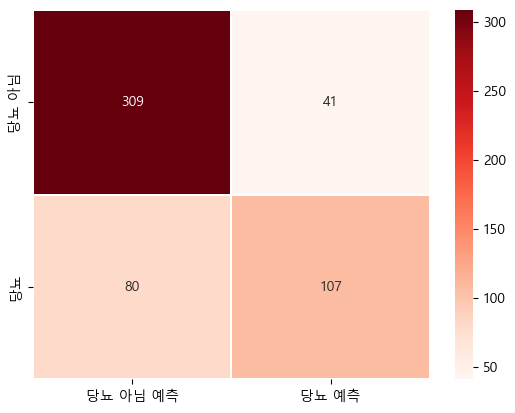

In [24]:
import seaborn as sb
sb.heatmap(c, annot=True, fmt='d', linewidths=0.2, cmap='Reds',
        xticklabels=['당뇨 아님 예측','당뇨 예측'], 
        yticklabels=['당뇨 아님', '당뇨'])
plt.show()

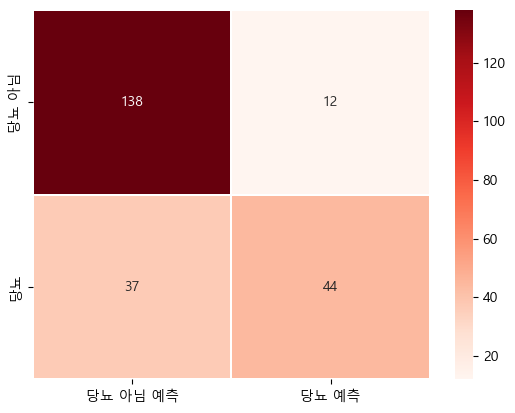

In [25]:
# 당뇨인데 당뇨 아님으로 예측한 값이 많음
pred_tt = model.predict(x_test) # 예측값
c = confusion_matrix(y_test, pred_tt) # (실제값, 예측값)

sb.heatmap(c, annot=True, fmt='d', linewidths=0.2, cmap='Reds',
        xticklabels=['당뇨 아님 예측','당뇨 예측'], 
        yticklabels=['당뇨 아님', '당뇨'])
plt.show() 